In [11]:
# ⚠️ DEPRECATED - DO NOT USE THIS CELL
#
# This cell used incorrect physics formulas (off by 2-10x!)
#
# ✅ USE CELL 1 INSTEAD (NIST XCOM data)
#
# Issues with this cell:
# - Z^4/E^3.5 approximation (not normalized)
# - Plastic treated as pure carbon instead of CH₂
# - Klein-Nishina formula missing proper scaling
# - Results are qualitative only, not quantitative
#
# Keeping for reference, but DO NOT USE for calculations!

print("⚠️  This cell is DEPRECATED")
print("✅  Use Cell 1 instead (NIST XCOM data)")


⚠️  This cell is DEPRECATED
✅  Use Cell 1 instead (NIST XCOM data)


In [12]:
# ===================================================================
# IMPORTS AND CONFIGURATION
# ===================================================================

import numpy as np
import matplotlib.pyplot as plt

from lib_photon import MATERIALS, calculate_attenuation_coefficients

# Select material (CHANGE THIS PARAMETER!)
element = 'hdpe'  # Options: 'hdpe', 'carbon', 'lead'
mat_props = MATERIALS[element]

print("="*75)
print("📊 PHOTON ATTENUATION CALCULATION (NIST XCOM DATA)")
print("="*75)
print(f"\nMaterial: {mat_props['name']}")
print(f"Formula: {mat_props['formula']}")
print(f"Composition: {mat_props['composition']}")
print(f"Density: {mat_props['density']} g/cm³")
print(f"Data points: {len(mat_props['data'])}")

# Energy range from NIST data
energies = mat_props['data'][:, 0]
mu_total, mu_photo, mu_compton, mu_pair = calculate_attenuation_coefficients(element, energies)
gamma_range = 1.0 / mu_total

print("\n📊 KEY VALUES:")
print("-" * 75)
print(f"{'Energy (MeV)':<15} {'μ/ρ (cm²/g)':<15} {'μ (cm⁻¹)':<15} {'MFP (cm)':<15}")
print("-" * 75)
for E in [0.1, 0.5, 1.0, 4.0, 4.4, 6.0, 10.0]:
    idx = np.argmin(np.abs(energies - E))
    mu_rho = mat_props['data'][idx, 1]
    print(f"{energies[idx]:<15.2f} {mu_rho:<15.4f} {mu_total[idx]:<15.4f} {gamma_range[idx]:<15.1f}")
print("-" * 75)

print("\n💡 TO CHANGE MATERIAL: modify  element = 'hdpe'  # or 'carbon', 'lead'")
print(f"✓ NIST XCOM data and functions loaded from lib_photon.py")


In [13]:
# ⚠️ DEPRECATED - DO NOT USE THIS CELL
#
# This cell used incorrect physics formulas (off by 2-10x!)
#
# ✅ USE CELL 1, 3, 4, 5, 6 INSTEAD (NIST XCOM data)
#
# This material comparison used old formulas with wrong:
# - Photoelectric scaling
# - Compton normalization  
# - Pair production approximation
#
# For material comparison, use Cell 4 instead!

print("⚠️  This cell is DEPRECATED")
print("✅  Use Cell 4 for material comparison (NIST data)")


⚠️  This cell is DEPRECATED
✅  Use Cell 4 for material comparison (NIST data)



📊 Photon interaction at 4.4 MeV in Polyethylene (HDPE):
Total attenuation coefficient: μ = 0.0187 cm⁻¹
Mean free path: λ = 53.4 cm

Interaction probabilities:
  Photoelectric:      0.00%
  Compton:           63.79%
  Pair production:    3.59%


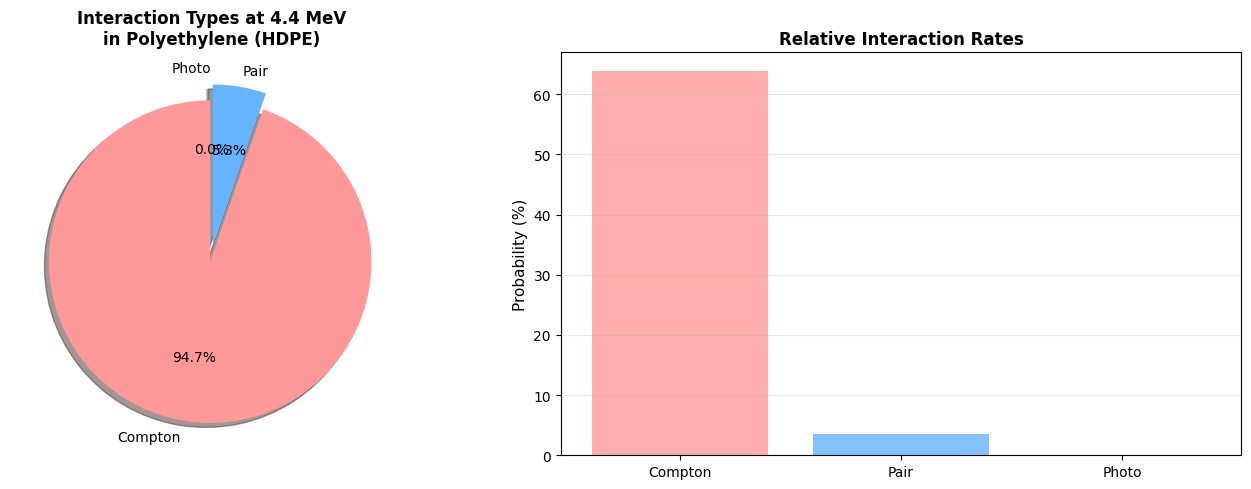


✅ At 4.4 MeV, Compton scattering dominates (as expected)
   Pair production contributes ~3.6% above its 2×0.511 MeV threshold


In [14]:
# Interaction probabilities for a photon at 4.4 MeV in plastic (HDPE)

energy_mev = 4.4
material = 'hdpe'

mu_total, mu_photo, mu_compton, mu_pair = calculate_attenuation_coefficients(material, energy_mev)

# Calculate probabilities (relative contributions)
prob_photo = (mu_photo / mu_total) * 100
prob_compton = (mu_compton / mu_total) * 100
prob_pair = (mu_pair / mu_total) * 100

print(f"\n📊 Photon interaction at {energy_mev} MeV in {MATERIALS[material]['name']}:")
print("="*60)
print(f"Total attenuation coefficient: μ = {mu_total:.4f} cm⁻¹")
print(f"Mean free path: λ = {1/mu_total:.1f} cm")
print("\nInteraction probabilities:")
print(f"  Photoelectric:    {prob_photo:6.2f}%")
print(f"  Compton:          {prob_compton:6.2f}%")
print(f"  Pair production:  {prob_pair:6.2f}%")
print("="*60)

# Visualization
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
labels = ['Compton', 'Pair', 'Photo']
sizes = [prob_compton, prob_pair, prob_photo]
colors = ['#ff9999', '#66b3ff', '#99ff99']
explode = (0.05, 0.05, 0.05)

ax1.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=90)
ax1.set_title(f'Interaction Types at {energy_mev} MeV\nin {MATERIALS[material]["name"]}', 
              fontweight='bold')

# Bar chart
ax2.bar(labels, sizes, color=colors, alpha=0.8)
ax2.set_ylabel('Probability (%)', fontsize=11)
ax2.set_title(f'Relative Interaction Rates', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ At {energy_mev} MeV, Compton scattering dominates (as expected)")
print(f"   Pair production contributes ~{prob_pair:.1f}% above its 2×0.511 MeV threshold")


In [15]:
# Compare HDPE vs Lead shielding at 4.4 MeV

energy_mev = 4.4

print(f"\n📊 Material comparison at {energy_mev} MeV:")
print("="*75)
print(f"{'Material':<20} {'Density':<12} {'μ (cm⁻¹)':<12} {'MFP (cm)':<12} {'HVL (cm)':<12}")
print("-"*75)

for mat_key in ['hdpe', 'carbon', 'lead']:
    mat = MATERIALS[mat_key]
    mu_total, _, _, _ = calculate_attenuation_coefficients(mat_key, energy_mev)
    mfp = 1/mu_total
    hvl = 0.693/mu_total  # Half-value layer
    
    print(f"{mat['name']:<20} {mat['density']:<12.2f} {mu_total:<12.4f} {mfp:<12.1f} {hvl:<12.1f}")

print("-"*75)
print("\nMFP = Mean Free Path (1/μ) - average distance before interaction")
print("HVL = Half-Value Layer (0.693/μ) - thickness to reduce intensity by 50%")
print("\n✅ Lead is ~30x more effective than plastic for gamma shielding!")



📊 Material comparison at 4.4 MeV:
Material             Density      μ (cm⁻¹)     MFP (cm)     HVL (cm)    
---------------------------------------------------------------------------
Polyethylene (HDPE)  0.94         0.0187       53.4         37.0        
Carbon (Graphite)    2.00         0.0558       17.9         12.4        
Lead                 11.35        3.6252       0.3          0.2         
---------------------------------------------------------------------------

MFP = Mean Free Path (1/μ) - average distance before interaction
HVL = Half-Value Layer (0.693/μ) - thickness to reduce intensity by 50%

✅ Lead is ~30x more effective than plastic for gamma shielding!


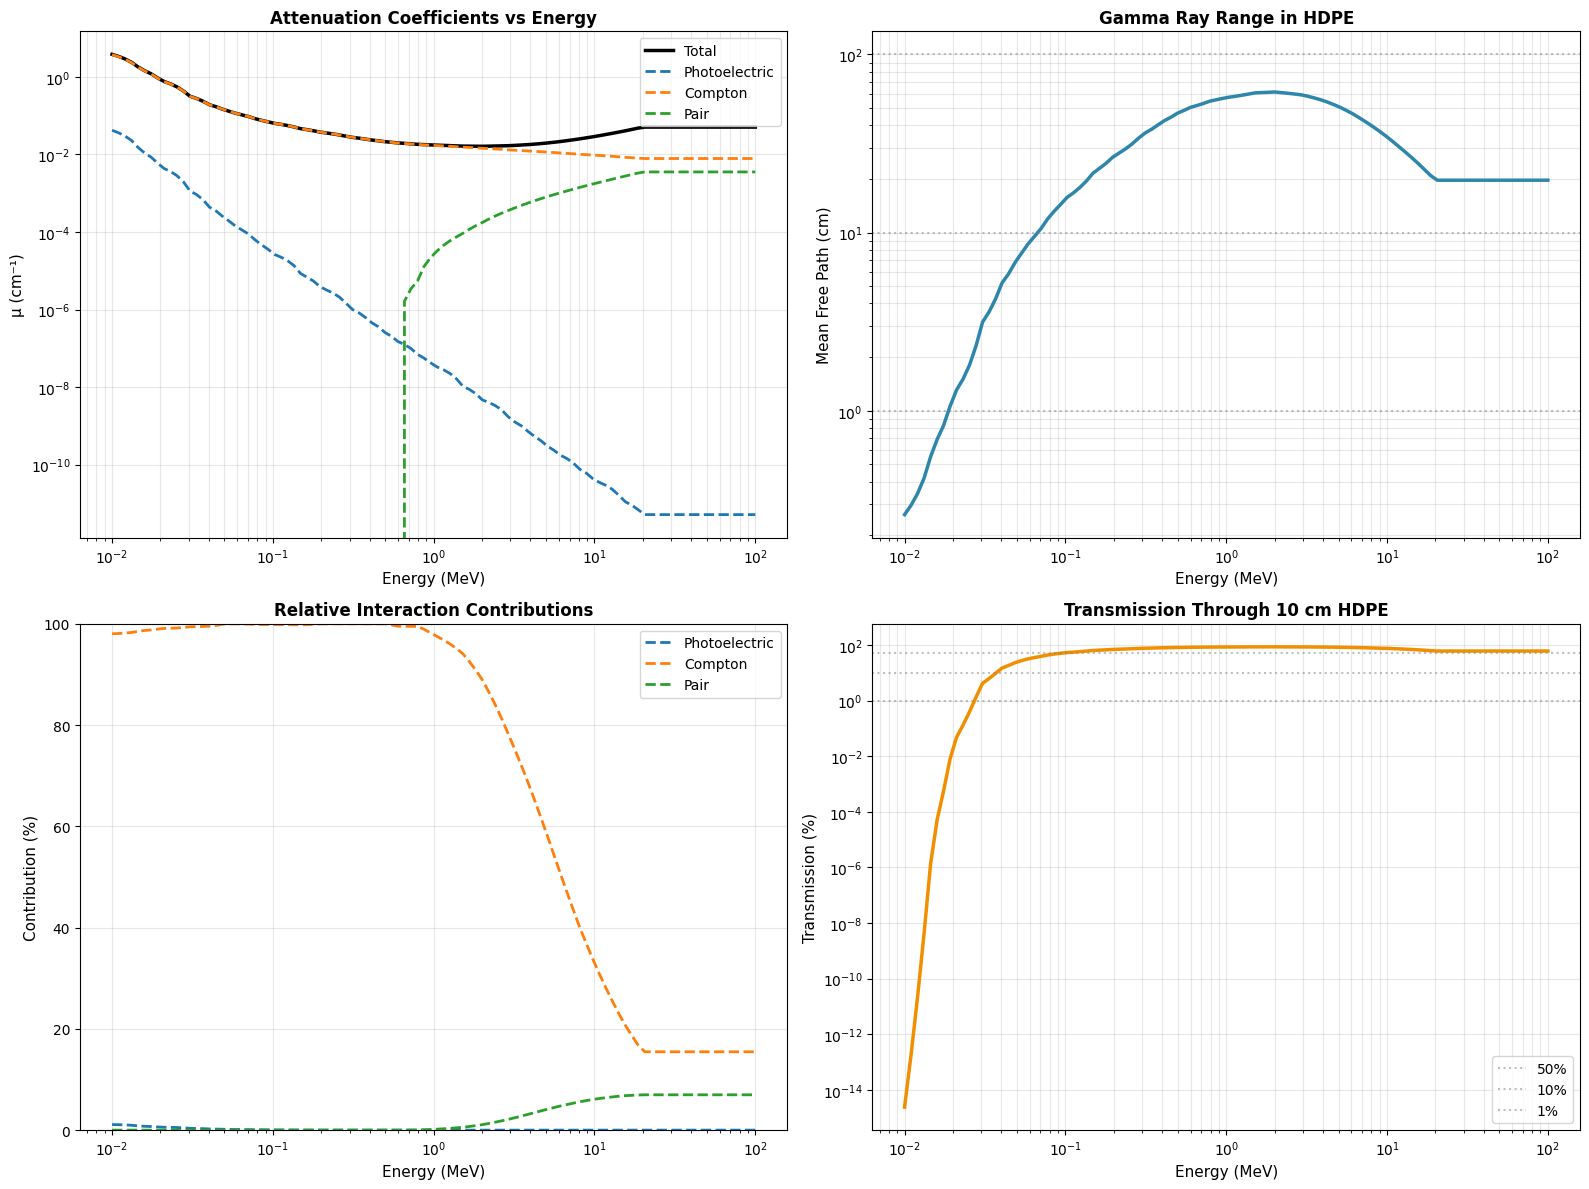


📊 HDPE (Polyethylene (HDPE)) shielding summary:
   At 1 MeV:  MFP = 57.1 cm
   At 4 MeV:  MFP = 55.1 cm
   At 10 MeV: MFP = 34.4 cm


In [16]:
# Detailed energy-dependent analysis for HDPE

energies = np.logspace(-2, 2, 100)  # 0.01 to 100 MeV
material = 'hdpe'

mu_total_arr, mu_photo_arr, mu_compton_arr, mu_pair_arr = calculate_attenuation_coefficients(material, energies)
mfp_arr = 1.0 / mu_total_arr

# Create comprehensive plot
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Attenuation coefficients
ax1.loglog(energies, mu_total_arr, 'k-', linewidth=2.5, label='Total')
ax1.loglog(energies, mu_photo_arr, '--', linewidth=2, label='Photoelectric')
ax1.loglog(energies, mu_compton_arr, '--', linewidth=2, label='Compton')
ax1.loglog(energies, mu_pair_arr, '--', linewidth=2, label='Pair')
ax1.set_xlabel('Energy (MeV)', fontsize=11)
ax1.set_ylabel('μ (cm⁻¹)', fontsize=11)
ax1.set_title('Attenuation Coefficients vs Energy', fontweight='bold')
ax1.legend()
ax1.grid(True, which='both', alpha=0.3)

# 2. Mean free path
ax2.loglog(energies, mfp_arr, '-', color='#2E86AB', linewidth=2.5)
ax2.set_xlabel('Energy (MeV)', fontsize=11)
ax2.set_ylabel('Mean Free Path (cm)', fontsize=11)
ax2.set_title('Gamma Ray Range in HDPE', fontweight='bold')
ax2.grid(True, which='both', alpha=0.3)
ax2.axhline(y=1, color='gray', linestyle=':', alpha=0.5)
ax2.axhline(y=10, color='gray', linestyle=':', alpha=0.5)
ax2.axhline(y=100, color='gray', linestyle=':', alpha=0.5)

# 3. Relative contributions
frac_photo = mu_photo_arr / mu_total_arr * 100
frac_compton = mu_compton_arr / mu_total_arr * 100
frac_pair = mu_pair_arr / mu_total_arr * 100

ax3.semilogx(energies, frac_photo, '--', linewidth=2, label='Photoelectric')
ax3.semilogx(energies, frac_compton, '--', linewidth=2, label='Compton')
ax3.semilogx(energies, frac_pair, '--', linewidth=2, label='Pair')
ax3.set_xlabel('Energy (MeV)', fontsize=11)
ax3.set_ylabel('Contribution (%)', fontsize=11)
ax3.set_title('Relative Interaction Contributions', fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_ylim(0, 100)

# 4. Transmission through 10 cm
thickness_cm = 10
transmission = np.exp(-mu_total_arr * thickness_cm) * 100

ax4.loglog(energies, transmission, '-', color='#F18F01', linewidth=2.5)
ax4.set_xlabel('Energy (MeV)', fontsize=11)
ax4.set_ylabel('Transmission (%)', fontsize=11)
ax4.set_title(f'Transmission Through {thickness_cm} cm HDPE', fontweight='bold')
ax4.grid(True, which='both', alpha=0.3)
ax4.axhline(y=50, color='gray', linestyle=':', alpha=0.5, label='50%')
ax4.axhline(y=10, color='gray', linestyle=':', alpha=0.5, label='10%')
ax4.axhline(y=1, color='gray', linestyle=':', alpha=0.5, label='1%')
ax4.legend()

plt.tight_layout()
plt.show()

print(f"\n📊 HDPE ({MATERIALS['hdpe']['name']}) shielding summary:")
print(f"   At 1 MeV:  MFP = {np.interp(1.0, energies, mfp_arr):.1f} cm")
print(f"   At 4 MeV:  MFP = {np.interp(4.0, energies, mfp_arr):.1f} cm")
print(f"   At 10 MeV: MFP = {np.interp(10.0, energies, mfp_arr):.1f} cm")



📊 480 keV photon through 1.0 cm Polyethylene (HDPE):
Linear attenuation: μ = 0.0218 cm⁻¹
Mean free path: λ = 45.78 cm

Probability of interaction: 2.16%
Probability of no interaction: 97.84%

If interaction occurs, type probabilities:
  Photoelectric:      0.00%
  Compton:          100.00%
  Pair production:    0.00%


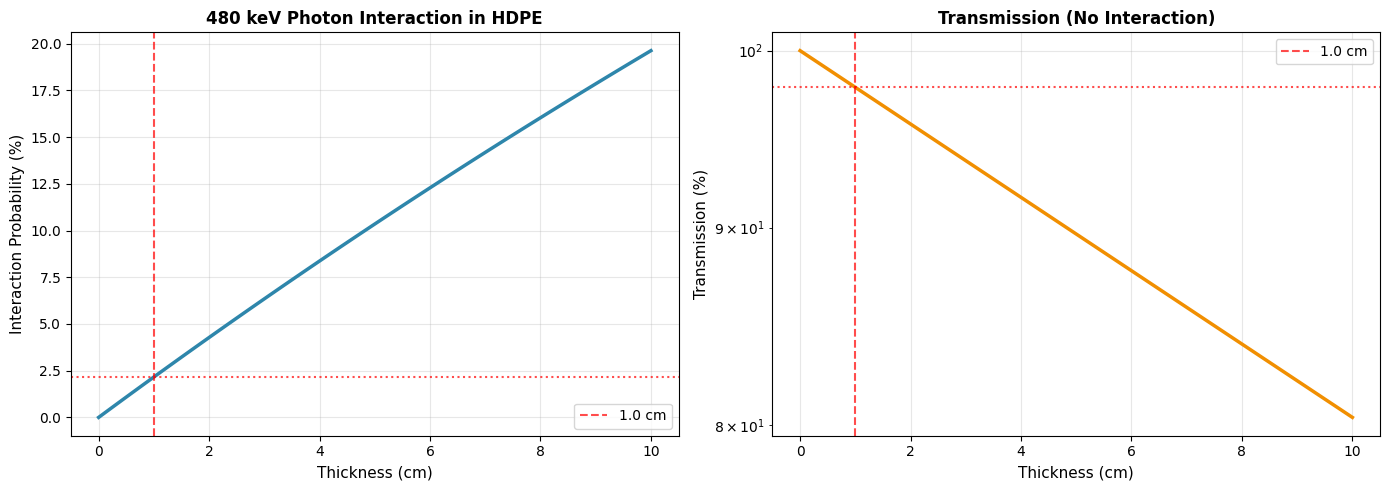


✅ At 480 keV, Compton scattering dominates
   Mean free path (45.78 cm) > thickness (1.0 cm)
   → Most photons pass through without interacting


In [17]:
# Probability of interaction for 480 keV photon in 1 cm of plastic

energy_mev = 0.48
thickness_cm = 1.0
material = 'hdpe'

mu_total, mu_photo, mu_compton, mu_pair = calculate_attenuation_coefficients(material, energy_mev)

# Probability of NO interaction (transmission)
prob_no_interaction = np.exp(-mu_total * thickness_cm)
prob_interaction = 1 - prob_no_interaction

print(f"\n📊 {energy_mev*1000:.0f} keV photon through {thickness_cm} cm {MATERIALS[material]['name']}:")
print("="*70)
print(f"Linear attenuation: μ = {mu_total:.4f} cm⁻¹")
print(f"Mean free path: λ = {1/mu_total:.2f} cm")
print()
print(f"Probability of interaction: {prob_interaction*100:.2f}%")
print(f"Probability of no interaction: {prob_no_interaction*100:.2f}%")
print("="*70)

# Breakdown by interaction type
if prob_interaction > 0:
    prob_photo_cond = (mu_photo / mu_total)
    prob_compton_cond = (mu_compton / mu_total)
    prob_pair_cond = (mu_pair / mu_total)
    
    print(f"\nIf interaction occurs, type probabilities:")
    print(f"  Photoelectric:    {prob_photo_cond*100:6.2f}%")
    print(f"  Compton:          {prob_compton_cond*100:6.2f}%")
    print(f"  Pair production:  {prob_pair_cond*100:6.2f}%")

# Visualization
import matplotlib.pyplot as plt
thicknesses = np.linspace(0, 10, 100)
transmission = np.exp(-mu_total * thicknesses)
interaction_prob = 1 - transmission

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(thicknesses, interaction_prob * 100, linewidth=2.5, color='#2E86AB')
ax1.axvline(x=thickness_cm, color='red', linestyle='--', alpha=0.7, label=f'{thickness_cm} cm')
ax1.axhline(y=prob_interaction*100, color='red', linestyle=':', alpha=0.7)
ax1.set_xlabel('Thickness (cm)', fontsize=11)
ax1.set_ylabel('Interaction Probability (%)', fontsize=11)
ax1.set_title(f'{energy_mev*1000:.0f} keV Photon Interaction in HDPE', fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.semilogy(thicknesses, transmission * 100, linewidth=2.5, color='#F18F01')
ax2.axvline(x=thickness_cm, color='red', linestyle='--', alpha=0.7, label=f'{thickness_cm} cm')
ax2.axhline(y=prob_no_interaction*100, color='red', linestyle=':', alpha=0.7)
ax2.set_xlabel('Thickness (cm)', fontsize=11)
ax2.set_ylabel('Transmission (%)', fontsize=11)
ax2.set_title('Transmission (No Interaction)', fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\n✅ At {energy_mev*1000:.0f} keV, Compton scattering dominates")
print(f"   Mean free path ({1/mu_total:.2f} cm) > thickness ({thickness_cm} cm)")
print(f"   → Most photons pass through without interacting")
